<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/23521013_Arief_Purnama_Muharram_IF5171_DL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IF5171 Deep Learning for Visual Recognition -- Week 7
___
Name: Arief Purnama Muharram<br>
NIM: 23521013

## Step 0: Prerequisites
___

### 0.1: Mount Google Drive

In [ ]:
from google.colab import drive


drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### 0.2: Install required packages

In [ ]:
!pip install numpy
!pip install tqdm
!pip install seaborn
!pip install torch
!pip install torchvision

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import tqdm
import seaborn as sns
import torch
import torchvision


print('NumPy version:', np.__version__)
print('Tqdm version:', tqdm.__version__)
print('Seaborn version:', sns.__version__)
print('Torch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)

NumPy version: 1.21.6
Tqdm version: 4.64.1
Seaborn version: 0.11.2
Torch version: 1.12.1+cu113
Torchvision version: 0.13.1+cu113


### 0.3: Predefined helper class

#### A: VizUtils class

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as F
from torchvision.utils import make_grid


plt.rcParams['savefig.bbox'] = 'tight'

class VizUtils:
  def __init__(self):
    super(VizUtils, self).__init__()

  def set_grid(self, D, num_cells=1, is_random=False):
    if type(D) is np.ndarray:
      A = torch.from_numpy(D)
    else:
      A = D
    if len(A.shape) == 3:
      (n, d1, d2) = A.shape
      c = 1
    elif len(A.shape) == 4:
      (n, c, d1, d2) = A.shape
    if not is_random:
      img_list = [torch.reshape(A[i], (c, d1, d2)) for i in range(num_cells)]
    else:
      img_list = [torch.reshape(A[i], (c, d1, d2)) for i in range(num_cells)]
    return make_grid(img_list)
  
  def show(self, imgs):
    if not isinstance(imgs, list):
      imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
      img = img.detach()
      img = F.to_pil_image(img)
      axs[0, i].imshow(np.asarray(img))
      axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

#### B: TrainUtils class

In [ ]:
import torch
from torch import nn
from torch import optim
from tqdm import tqdm


class TrainUtils:
  def __init__(self, model, loss_fn, optimizer, learning_rate=1e-3, device=None):
    super(TrainUtils, self).__init__()
    # Supported loss function
    self.supported_loss_fn = ['CrossEntropyLoss']
    # Supported optimizer
    self.supported_optim = ['SGD', 'Adam']
    # Learning rate
    self.learning_rate = learning_rate
    # Set model
    self.model = model
    # Set loss function
    if loss_fn not in self.supported_loss_fn:
      raise ValueError('Loss function is not supported!')
    else:
      if loss_fn == 'CrossEntropyLoss':
        self.loss_fn = nn.CrossEntropyLoss()
      else:
        self.loss_fn = None
    # Set optimizer
    if optimizer not in self.supported_optim:
      raise ValueError('Optimizer is not supported!')
    else:
      if optimizer == 'SGD':
        self.optimizer = optim.SGD(
            model.parameters(),
            lr = self.learning_rate
        )
      elif optimizer == 'Adam':
        self.optimizer = optim.Adam(
            model.parameters(),
            lr = self.learning_rate
        )
      else:
        self.optimizer = None
    if device is not None:
      self.device = device
    else:
      if torch.cuda.is_available():
        self.device = 'cuda'
        gpu_info = !nvidia-smi
        gpu_info = '\n'.join(gpu_info)
        print('Using NVidia Cuda!')
        print(gpu_info, '\n')
      else:
        self.device = 'cpu'
        print('Using CPU!\n')
  
  def set_model(self, model):
    self.model = model
  
  def set_loss_fn(self, loss_fn):
    if loss_fn not in self.supported_loss_fn:
      raise ValueError('Loss function is not supported!')
    else:
      if loss_fn == 'CrossEntropyLoss':
        self.loss_fn = nn.CrossEntropyLoss()
      else:
        self.loss_fn = None
  
  def set_optimizer(self, optimizer):
    if optimizer not in self.supported_optim:
      raise ValueError('Optimizer is not supported!')
    else:
      if optimizer == 'SGD':
        self.optimizer = optim.SGD(
            self.model.parameters(),
            lr = self.learning_rate
        )
      elif optimizer == 'Adam':
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr = self.learning_rate
        )
      else:
        self.optimizer = None
  
  def set_learning_rate(self, learning_rate):
    self.learning_rate = learning_rate

  def train(self, train_dataloader, print_log=False):
    model = self.model
    loss_fn = self.loss_fn
    optimizer = self.optimizer
    device = self.device
    loss_history = []
    for batch, (X, y) in enumerate(tqdm(train_dataloader)):
      # Switch to train mode
      model.train()
      X, y, model = X.to(device), y.to(device), model.to(device)
      # Compute error
      pred = model(X)
      loss = loss_fn(pred, y)
      # Backpropagation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if batch % 100 == 0:
        loss_history.append([batch, loss])
    if print_log == True:
      print('Loss over batches:')
      print(' Batch\tLoss')
      for item in loss_history:
        print(f' {item[0]}\t{item[1]:>7f}')
    return (loss_history)

  def test(self, dataloader, print_log=False):
    model = self.model
    loss_fn = self.loss_fn
    device = self.device
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
      for X, y in dataloader:
        X, y, model = X.to(device), y.to(device), model.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    if print_log == True:
      print(f'Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}')
    return (correct)

#### C: Models class

##### C.1: SoftmaxClassifier model

In [ ]:
from torch import nn


class SoftmaxClassifier(nn.Module):
  def __init__(self, d_out=10):
    super(SoftmaxClassifier, self).__init__()
    self.flatten = nn.Flatten()
    self.network = nn.Sequential(
        nn.LazyLinear(d_out)
    )
    
  def forward(self, x):
    x = self.flatten(x)
    logits = self.network(x)
    return logits

##### C.2: MLP model

In [ ]:
from torch import nn


class MLP(nn.Module):
  def __init__(self, d_out=10):
    super(MLP, self).__init__()
    self.flatten = nn.Flatten()
    self.network = nn.Sequential(
        nn.LazyLinear(512),
        nn.ReLU(),
        nn.LazyLinear(512),
        nn.ReLU(),
        nn.LazyLinear(d_out)
    )
  
  def forward(self, x):
    x = self.flatten(x)
    logits = self.network(x)
    return logits

##### C.3: ConvNet model

In [ ]:
from torch import nn


class ConvNet(nn.Module):
  def __init__(self, d_out=10):
    super(ConvNet, self).__init__()
    self.conv1 = nn.LazyConv2d(out_channels=32, kernel_size=3)
    self.conv2 = nn.LazyConv2d(out_channels=32, kernel_size=3)
    self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv3 = nn.LazyConv2d(out_channels=64, kernel_size=3)
    self.conv4 = nn.LazyConv2d(out_channels=64, kernel_size=3)
    self.max_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1 = nn.LazyLinear(512)
    self.relu1 = nn.ReLU()
    self.fc2 = nn.LazyLinear(d_out)
  
  def forward(self, x):
    out = self.conv1(x)
    out = self.conv2(out)
    out = self.max_pool1(out)

    out = self.conv3(out)
    out = self.conv4(out)
    out = self.max_pool2(out)

    out = out.reshape(out.size(0), -1)

    out = self.fc1(out)
    out = self.relu1(out)
    out = self.fc2(out)
    return out

##### C.4: ConvNetWithDropout model

In [ ]:
from torch import nn


class ConvNetWithDropout(nn.Module):
  def __init__(self, d_out=10, dropout=0.5):
    super(ConvNetWithDropout, self).__init__()
    self.conv1 = nn.LazyConv2d(out_channels=32, kernel_size=3)
    self.conv2 = nn.LazyConv2d(out_channels=32, kernel_size=3)
    self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv3 = nn.LazyConv2d(out_channels=64, kernel_size=3)
    self.conv4 = nn.LazyConv2d(out_channels=64, kernel_size=3)
    self.max_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.dropout1 = nn.Dropout(p=dropout)

    self.fc1 = nn.LazyLinear(512)
    self.relu1 = nn.ReLU()

    self.dropout2 = nn.Dropout(p=dropout)

    self.fc2 = nn.LazyLinear(d_out)
  
  def forward(self, x):
    out = self.conv1(x)
    out = self.conv2(out)
    out = self.max_pool1(out)

    out = self.conv3(out)
    out = self.conv4(out)
    out = self.max_pool2(out)

    out = out.reshape(out.size(0), -1)

    out = self.dropout1(out)

    out = self.fc1(out)
    out = self.relu1(out)

    out = self.dropout2(out)

    out = self.fc2(out)
    return out

### 0.4: Define constants

In [ ]:
import os


GDRIVE_DIR = '/content/drive/MyDrive/IF5171-DL-1/'
DATA_DIR = 'data'
MODEL_DIR = 'models'
LOG_DIR = 'logs'

EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

## Step 1: Load Dataset
___

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms as T


vu = VizUtils()

### 1.1: MNIST dataset

In [ ]:
mnist_training_data = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=T.ToTensor()
)

mnist_test_data = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=T.ToTensor()
)

In [ ]:
mnist_train_dataloader = DataLoader(mnist_training_data, batch_size=BATCH_SIZE)
mnist_test_dataloader = DataLoader(mnist_test_data, batch_size=BATCH_SIZE)

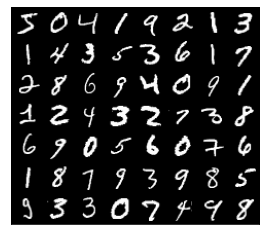

In [ ]:
grid = vu.set_grid(mnist_train_dataloader.dataset.data, num_cells=56)
vu.show(grid)

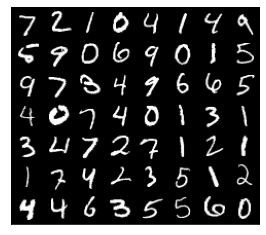

In [ ]:
grid = vu.set_grid(mnist_test_dataloader.dataset.data, num_cells=56)
vu.show(grid)

In [ ]:
from sklearn.model_selection import train_test_split


mnist_training_data, mnist_validation_data = train_test_split(
    mnist_training_data, test_size=0.33
)

mnist_train_dataloader = DataLoader(mnist_training_data, batch_size=BATCH_SIZE)
mnist_validation_dataloader = DataLoader(mnist_validation_data, batch_size=BATCH_SIZE)

### 1.2: SVHN dataset

In [ ]:
svhn_training_data = datasets.SVHN(
    root=DATA_DIR,
    split='train',
    download=True,
    transform=T.ToTensor()
)

svhn_test_data = datasets.SVHN(
    root=DATA_DIR,
    split='test',
    download=True,
    transform=T.ToTensor()
)

Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat


In [ ]:
svhn_train_dataloader = DataLoader(svhn_training_data, batch_size=BATCH_SIZE)
svhn_test_dataloader = DataLoader(svhn_test_data, batch_size=BATCH_SIZE)

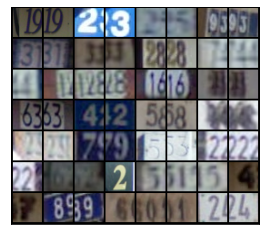

In [ ]:
grid = vu.set_grid(svhn_train_dataloader.dataset.data, num_cells=56)
vu.show(grid)

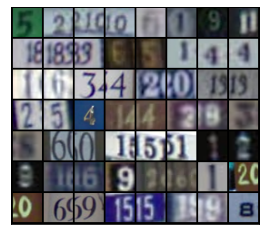

In [ ]:
grid = vu.set_grid(svhn_test_dataloader.dataset.data, num_cells=56)
vu.show(grid)

In [ ]:
from sklearn.model_selection import train_test_split


svhn_training_data, svhn_validation_data = train_test_split(
    svhn_training_data, test_size=0.33
)

svhn_train_dataloader = DataLoader(svhn_training_data, batch_size=BATCH_SIZE)
svhn_validation_dataloader = DataLoader(svhn_validation_data, batch_size=BATCH_SIZE)

## Step 2: Model Training
___

### 2.1: Train wrapper

In [ ]:
import os
import time as timer
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def train_wrapper(model, trainer, 
                  train_dataloader, validation_dataloader, test_dataloader, 
                  epochs=10, saved_model_name='model.pth', log_name='log.txt'):
  model_path = os.path.join(GDRIVE_DIR, MODEL_DIR)
  log_path = os.path.join(GDRIVE_DIR, LOG_DIR)

  if not os.path.exists(model_path):
    os.makedirs(model_path)
  if not os.path.exists(log_path):
    os.makedirs(log_path)

  model_path = os.path.join(model_path, saved_model_name)
  log_path = os.path.join(log_path, log_name)

  train_history = []

  with open(log_path, 'a') as fh:
    fh.write('epoch\ttrain_acc\ttest_acc\n')
    for epoch in range(epochs):
      print(f"Epoch {epoch+1} out of {epochs}\n ------------")
      start = timer.time()
      # Train model
      trainer.train(train_dataloader, print_log=False)  
      elapsed_time = timer.time() - start
      print(f"Training time: {elapsed_time:>.2f} seconds")
      # Evaluate model: get training accuracy 
      training_accuracy = trainer.test(validation_dataloader, print_log=False)
      # Evaluate model: get testing accuracy
      testing_accuracy = trainer.test(test_dataloader, print_log=False)
      # Append history
      train_history.append([epoch, training_accuracy, testing_accuracy])
      # Write log
      fh.write(f'{epoch}\t{training_accuracy}\t{testing_accuracy}\n')
      # Save model
      torch.save(model.state_dict(), model_path)
      print(f"Model {model_path} stored!\n")
  
  train_history = pd.DataFrame(train_history, columns=['epoch', 'train_acc', 'test_acc'])

  # Plot accurcy
  plt.figure()
  train_history.drop(columns=['epoch']).plot.line()
  plt.title(f'{saved_model_name} Accuracy History over Epochs\n', fontdict={
      'fontsize': 15, 'fontweight': 'bold'
  })
  plt.xlabel('Epoch', fontdict={
      'fontsize': 10
  })
  plt.ylabel('Accuracy', fontdict={
      'fontsize': 10
  })
  plt.show()

  print("Done!")

### 2.2: MNIST-to-MNIST

#### A: MLP classifier

##### A.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 10:29:39 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    48W / 400W |      3MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:07<00:00, 82.35it/s] 


Training time: 7.64 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_mlp_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 561.08it/s]


...

100%|██████████| 629/629 [00:01<00:00, 622.23it/s]


Training time: 1.02 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_mlp_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 628.88it/s]


Training time: 1.00 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_mlp_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

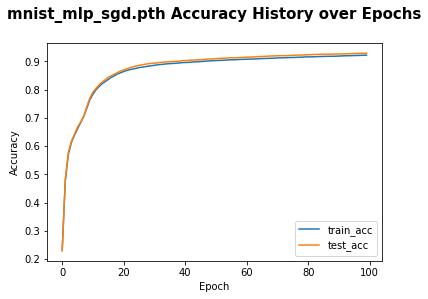

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=mnist_train_dataloader, 
              validation_dataloader=mnist_validation_dataloader, 
              test_dataloader=mnist_test_dataloader,
              epochs=100, saved_model_name='mnist_mlp_sgd.pth', log_name='mnist_mlp_sgd.txt')

##### A.2: Using ADAM optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 10:33:27 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    55W / 400W |   1350MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:01<00:00, 453.63it/s]


Training time: 1.39 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_mlp_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 430.67it/s]


...

100%|██████████| 629/629 [00:01<00:00, 467.55it/s]


Training time: 1.35 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_mlp_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 470.50it/s]


Training time: 1.35 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_mlp_adam.pth stored!



<Figure size 432x288 with 0 Axes>

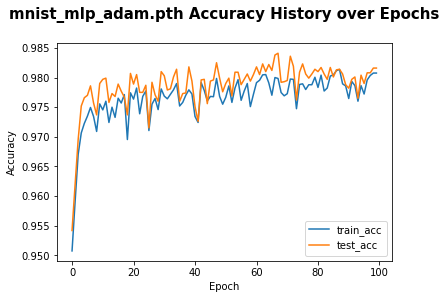

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=mnist_train_dataloader, 
              validation_dataloader=mnist_validation_dataloader, 
              test_dataloader=mnist_test_dataloader,
              epochs=100, saved_model_name='mnist_mlp_adam.pth', log_name='mnist_mlp_adam.txt')

#### B: ConvNet classifier

##### B.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 10:37:44 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    53W / 400W |   1356MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:07<00:00, 88.19it/s] 


Training time: 7.14 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_convnet_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 300.96it/s]


...

100%|██████████| 629/629 [00:02<00:00, 299.16it/s]


Training time: 2.11 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_convnet_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 297.63it/s]


Training time: 2.12 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_convnet_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

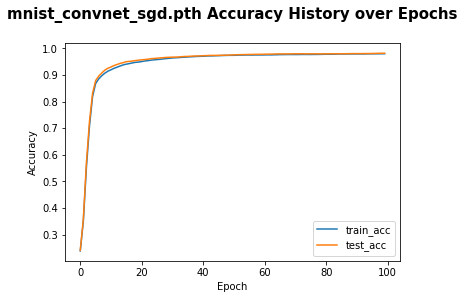

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=mnist_train_dataloader, 
              validation_dataloader=mnist_validation_dataloader, 
              test_dataloader=mnist_test_dataloader,
              epochs=100, saved_model_name='mnist_convnet_sgd.pth', log_name='mnist_convnet_sgd.txt')

##### B.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 10:43:43 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0    53W / 400W |   1888MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:02<00:00, 229.03it/s]


Training time: 2.75 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_convnet_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 230.93it/s]


...

100%|██████████| 629/629 [00:02<00:00, 228.29it/s]


Training time: 2.76 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_convnet_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 228.06it/s]


Training time: 2.76 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist_convnet_adam.pth stored!



<Figure size 432x288 with 0 Axes>

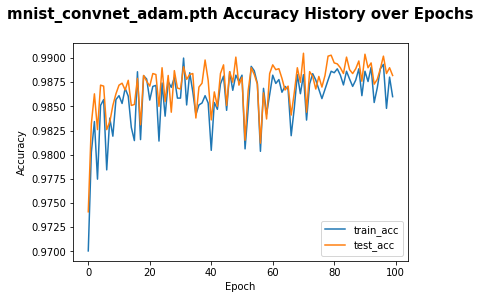

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=mnist_train_dataloader, 
              validation_dataloader=mnist_validation_dataloader, 
              test_dataloader=mnist_test_dataloader,
              epochs=100, saved_model_name='mnist_convnet_adam.pth', log_name='mnist_convnet_adam.txt')

### 2.3: SVHN-to-SVHN

#### A: MLP classifier

##### A.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 10:50:46 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0    54W / 400W |   1902MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:01<00:00, 474.46it/s]


Training time: 1.62 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_mlp_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 490.15it/s]


...

100%|██████████| 767/767 [00:01<00:00, 499.59it/s]


Training time: 1.54 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_mlp_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 498.37it/s]


Training time: 1.54 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_mlp_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

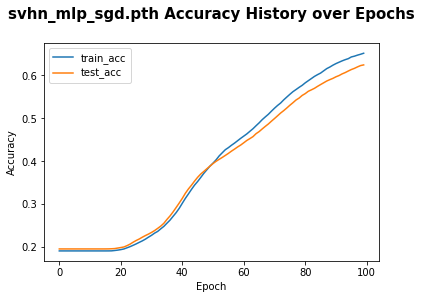

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=svhn_train_dataloader, 
              validation_dataloader=svhn_validation_dataloader, 
              test_dataloader=svhn_test_dataloader,
              epochs=100, saved_model_name='svhn_mlp_sgd.pth', log_name='svhn_mlp_sgd.txt')

##### A.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:00:10 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1902MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:01<00:00, 384.48it/s]


Training time: 2.00 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_mlp_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 388.66it/s]


...

100%|██████████| 767/767 [00:01<00:00, 384.43it/s]


Training time: 2.00 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_mlp_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 390.20it/s]


Training time: 1.97 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_mlp_adam.pth stored!



<Figure size 432x288 with 0 Axes>

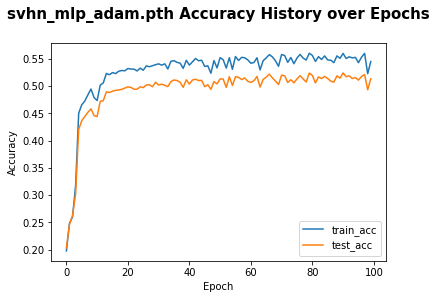

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=svhn_train_dataloader, 
              validation_dataloader=svhn_validation_dataloader, 
              test_dataloader=svhn_test_dataloader,
              epochs=100, saved_model_name='svhn_mlp_adam.pth', log_name='svhn_mlp_adam.txt')

#### B: ConvNet classifier

##### B.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:10:18 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1902MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:02<00:00, 274.17it/s]


Training time: 2.80 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_convnet_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:02<00:00, 279.10it/s]


...

100%|██████████| 767/767 [00:02<00:00, 282.42it/s]


Training time: 2.72 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_convnet_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:02<00:00, 278.10it/s]


Training time: 2.76 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_convnet_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

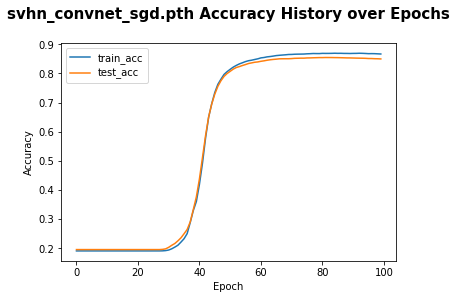

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=svhn_train_dataloader, 
              validation_dataloader=svhn_validation_dataloader, 
              test_dataloader=svhn_test_dataloader,
              epochs=100, saved_model_name='svhn_convnet_sgd.pth', log_name='svhn_convnet_sgd.txt')

##### B.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:22:21 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:03<00:00, 214.33it/s]


Training time: 3.58 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_convnet_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:03<00:00, 216.00it/s]


...

100%|██████████| 767/767 [00:03<00:00, 214.44it/s]


Training time: 3.58 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_convnet_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:03<00:00, 215.83it/s]


Training time: 3.56 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn_convnet_adam.pth stored!



<Figure size 432x288 with 0 Axes>

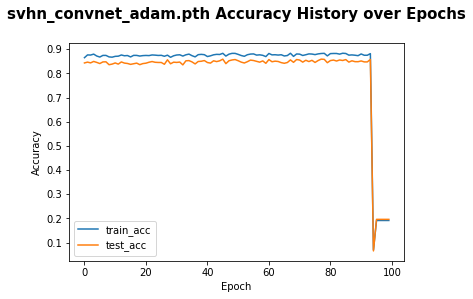

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=svhn_train_dataloader, 
              validation_dataloader=svhn_validation_dataloader, 
              test_dataloader=svhn_test_dataloader,
              epochs=100, saved_model_name='svhn_convnet_adam.pth', log_name='svhn_convnet_adam.txt')

### 2.4: SVHN-to-MNIST

In [ ]:
grayscale_svhn_training_data = datasets.SVHN(
    root=DATA_DIR,
    split='train',
    download=True,
    transform=T.Compose([
        T.Resize(28),
        T.Grayscale(num_output_channels=1),
        T.ToTensor()
    ])
)

Using downloaded and verified file: data/train_32x32.mat


In [ ]:
grayscale_mnist_test_data = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=T.Compose([
        T.Resize(28),
        T.Grayscale(num_output_channels=1),
        T.ToTensor()
    ])
)

In [ ]:
from sklearn.model_selection import train_test_split


grayscale_svhn_training_data, grayscale_svhn_validation_data = train_test_split(
    grayscale_svhn_training_data, test_size=0.33
)

grayscale_svhn_train_dataloader = DataLoader(grayscale_svhn_training_data, batch_size=BATCH_SIZE)
grayscale_svhn_validation_dataloader = DataLoader(grayscale_svhn_validation_data, batch_size=BATCH_SIZE)
grayscale_mnist_test_dataloader = DataLoader(grayscale_mnist_test_data, batch_size=BATCH_SIZE)

#### A: MLP classifier

##### A.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:35:59 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:01<00:00, 603.94it/s]


Training time: 1.27 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_mlp_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 607.10it/s]


...

100%|██████████| 767/767 [00:01<00:00, 603.67it/s]


Training time: 1.27 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_mlp_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 603.58it/s]


Training time: 1.27 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_mlp_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

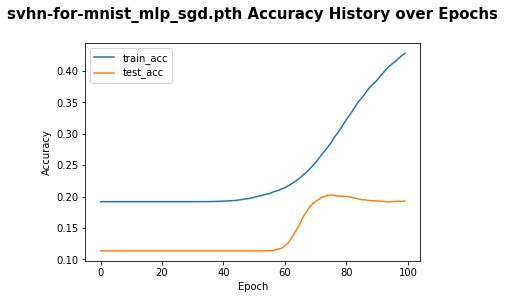

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=grayscale_svhn_train_dataloader, 
              validation_dataloader=grayscale_svhn_validation_dataloader, 
              test_dataloader=grayscale_mnist_test_dataloader,
              epochs=100, saved_model_name='svhn-for-mnist_mlp_sgd.pth', log_name='svhn-for-mnist_mlp_sgd.txt')

##### A.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:40:48 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    53W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:01<00:00, 449.51it/s]


Training time: 1.71 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_mlp_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 452.08it/s]


...

100%|██████████| 767/767 [00:01<00:00, 454.78it/s]


Training time: 1.69 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_mlp_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:01<00:00, 451.86it/s]


Training time: 1.70 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_mlp_adam.pth stored!



<Figure size 432x288 with 0 Axes>

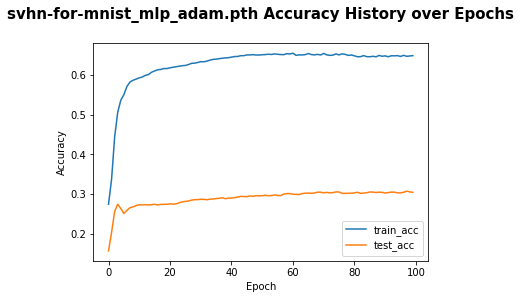

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=grayscale_svhn_train_dataloader, 
              validation_dataloader=grayscale_svhn_validation_dataloader, 
              test_dataloader=grayscale_mnist_test_dataloader,
              epochs=100, saved_model_name='svhn-for-mnist_mlp_adam.pth', log_name='svhn-for-mnist_mlp_adam.txt')

#### B: ConvNet classifier

##### B.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:46:19 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:02<00:00, 300.48it/s]


Training time: 2.56 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_convnet_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:02<00:00, 305.12it/s]


...

100%|██████████| 767/767 [00:02<00:00, 300.18it/s]


Training time: 2.56 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_convnet_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:02<00:00, 303.03it/s]


Training time: 2.54 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_convnet_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

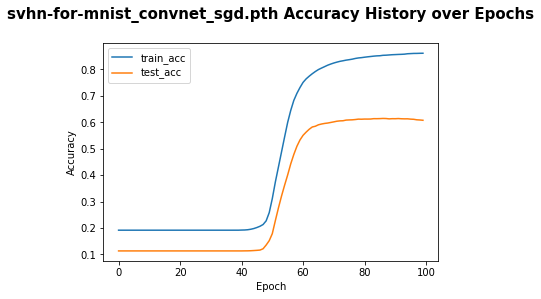

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=grayscale_svhn_train_dataloader, 
              validation_dataloader=grayscale_svhn_validation_dataloader, 
              test_dataloader=grayscale_mnist_test_dataloader,
              epochs=100, saved_model_name='svhn-for-mnist_convnet_sgd.pth', log_name='svhn-for-mnist_convnet_sgd.txt')

##### B.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 11:53:39 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 767/767 [00:03<00:00, 230.73it/s]


Training time: 3.33 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_convnet_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 767/767 [00:03<00:00, 230.45it/s]


...

100%|██████████| 767/767 [00:03<00:00, 230.53it/s]


Training time: 3.33 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_convnet_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 767/767 [00:03<00:00, 228.28it/s]


Training time: 3.37 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/svhn-for-mnist_convnet_adam.pth stored!



<Figure size 432x288 with 0 Axes>

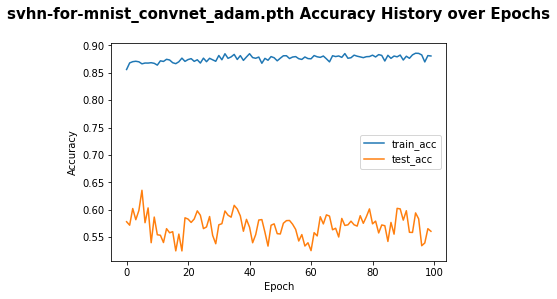

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=grayscale_svhn_train_dataloader, 
              validation_dataloader=grayscale_svhn_validation_dataloader, 
              test_dataloader=grayscale_mnist_test_dataloader,
              epochs=100, saved_model_name='svhn-for-mnist_convnet_adam.pth', log_name='svhn-for-mnist_convnet_adam.txt')

### 2.5: MNIST-to-SVHN

In [ ]:
grayscale_mnist_training_data = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=T.Compose([
        T.Resize(28),
        T.Grayscale(num_output_channels=1),
        T.ToTensor()
    ])
)

In [ ]:
grayscale_svhn_test_data = datasets.SVHN(
    root=DATA_DIR,
    split='test',
    download=True,
    transform=T.Compose([
        T.Resize(28),
        T.Grayscale(num_output_channels=1),
        T.ToTensor()
    ])
)

Using downloaded and verified file: data/test_32x32.mat


In [ ]:
from sklearn.model_selection import train_test_split


grayscale_mnist_training_data, grayscale_mnist_validation_data = train_test_split(
    grayscale_mnist_training_data, test_size=0.33
)

grayscale_mnist_train_dataloader = DataLoader(grayscale_mnist_training_data, batch_size=BATCH_SIZE)
grayscale_mnist_validation_dataloader = DataLoader(grayscale_mnist_validation_data, batch_size=BATCH_SIZE)
grayscale_svhn_test_dataloader = DataLoader(grayscale_svhn_test_data, batch_size=BATCH_SIZE)

#### A: MLP classifier

##### A.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 12:02:30 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:01<00:00, 603.41it/s]


Training time: 1.05 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_mlp_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 605.26it/s]


...

100%|██████████| 629/629 [00:01<00:00, 609.67it/s]


Training time: 1.04 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_mlp_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 606.93it/s]


Training time: 1.04 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_mlp_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

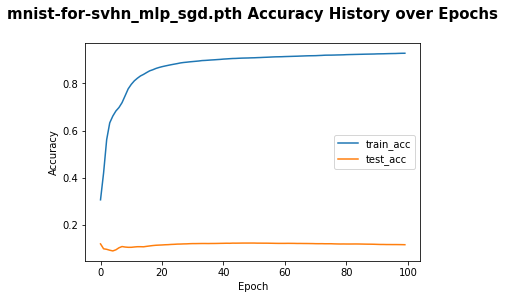

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=grayscale_mnist_train_dataloader, 
              validation_dataloader=grayscale_mnist_validation_dataloader, 
              test_dataloader=grayscale_svhn_test_dataloader,
              epochs=100, saved_model_name='mnist-for-svhn_mlp_sgd.pth', log_name='mnist-for-svhn_mlp_sgd.txt')

##### A.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 12:12:16 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:01<00:00, 452.50it/s]


Training time: 1.39 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_mlp_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 452.24it/s]


...

100%|██████████| 629/629 [00:01<00:00, 457.46it/s]


Training time: 1.38 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_mlp_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:01<00:00, 452.03it/s]


Training time: 1.40 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_mlp_adam.pth stored!



<Figure size 432x288 with 0 Axes>

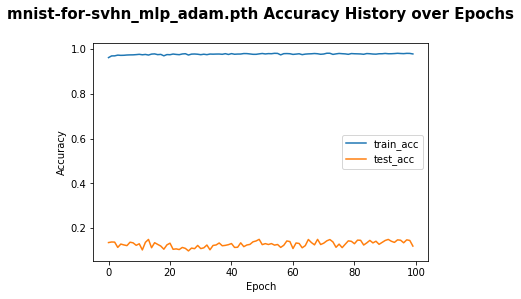

Done!


In [ ]:
model = MLP(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=grayscale_mnist_train_dataloader, 
              validation_dataloader=grayscale_mnist_validation_dataloader, 
              test_dataloader=grayscale_svhn_test_dataloader,
              epochs=100, saved_model_name='mnist-for-svhn_mlp_adam.pth', log_name='mnist-for-svhn_mlp_adam.txt')

#### B: ConvNet classifier

##### B.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 12:22:37 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:02<00:00, 303.20it/s]


Training time: 2.08 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 304.33it/s]


...

100%|██████████| 629/629 [00:02<00:00, 301.79it/s]


Training time: 2.09 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 302.32it/s]


Training time: 2.09 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

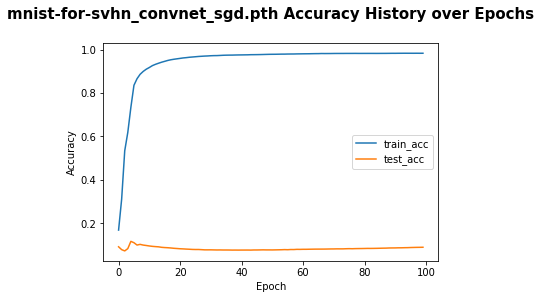

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=grayscale_mnist_train_dataloader, 
              validation_dataloader=grayscale_mnist_validation_dataloader, 
              test_dataloader=grayscale_svhn_test_dataloader,
              epochs=100, saved_model_name='mnist-for-svhn_convnet_sgd.pth', log_name='mnist-for-svhn_convnet_sgd.txt')

##### B.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 12:34:48 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    54W / 400W |   1938MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:02<00:00, 227.46it/s]


Training time: 2.77 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 230.65it/s]


...

100%|██████████| 629/629 [00:02<00:00, 228.07it/s]


Training time: 2.76 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 227.85it/s]


Training time: 2.77 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_adam.pth stored!



<Figure size 432x288 with 0 Axes>

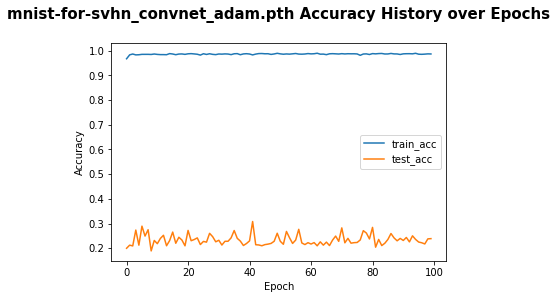

Done!


In [ ]:
model = ConvNet(d_out=10)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=grayscale_mnist_train_dataloader, 
              validation_dataloader=grayscale_mnist_validation_dataloader, 
              test_dataloader=grayscale_svhn_test_dataloader,
              epochs=100, saved_model_name='mnist-for-svhn_convnet_adam.pth', log_name='mnist-for-svhn_convnet_adam.txt')

### 2.5: MNIST-to-SVHN optimization

In [ ]:
grayscale_mnist_training_data = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=T.Compose([
        T.AutoAugment(T.AutoAugmentPolicy.SVHN),
        T.Resize(28),
        T.Grayscale(num_output_channels=1),
        T.ToTensor(),
        T.Normalize((0.485), (0.229))
    ])
)

In [ ]:
grayscale_svhn_test_data = datasets.SVHN(
    root=DATA_DIR,
    split='test',
    download=True,
    transform=T.Compose([
        T.AutoAugment(T.AutoAugmentPolicy.SVHN),
        T.Resize(28),
        T.Grayscale(num_output_channels=1),
        T.ToTensor(),
        T.Normalize((0.485), (0.229))
    ])
)

Using downloaded and verified file: data/test_32x32.mat


In [ ]:
from sklearn.model_selection import train_test_split


grayscale_mnist_training_data, grayscale_mnist_validation_data = train_test_split(
    grayscale_mnist_training_data, test_size=0.33
)

grayscale_mnist_train_dataloader = DataLoader(grayscale_mnist_training_data, batch_size=BATCH_SIZE)
grayscale_mnist_validation_dataloader = DataLoader(grayscale_mnist_validation_data, batch_size=BATCH_SIZE)
grayscale_svhn_test_dataloader = DataLoader(grayscale_svhn_test_data, batch_size=BATCH_SIZE)

#### B: ConvNet classifier

##### B.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 19:56:37 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P0    43W / 400W |      3MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:13<00:00, 48.11it/s] 


Training time: 13.08 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 296.49it/s]


...

100%|██████████| 629/629 [00:02<00:00, 298.30it/s]


Training time: 2.11 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 296.09it/s]


Training time: 2.13 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

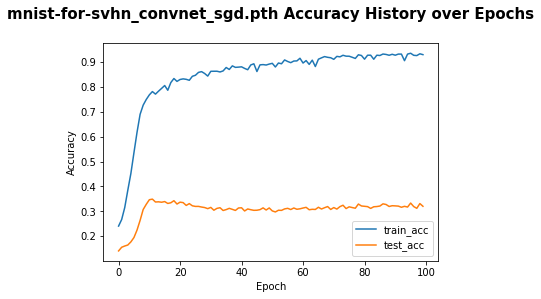

Done!


In [ ]:
model = ConvNetWithDropout(d_out=10, dropout=0.5)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=grayscale_mnist_train_dataloader, 
              validation_dataloader=grayscale_mnist_validation_dataloader, 
              test_dataloader=grayscale_svhn_test_dataloader,
              epochs=100, saved_model_name='mnist-for-svhn_convnet_sgd.pth', log_name='mnist-for-svhn_convnet_sgd.txt')

##### B.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 20:28:43 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0    49W / 400W |   1882MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 629/629 [00:02<00:00, 219.77it/s]


Training time: 2.87 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 225.16it/s]


...

100%|██████████| 629/629 [00:02<00:00, 224.00it/s]


Training time: 2.81 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 629/629 [00:02<00:00, 224.39it/s]


Training time: 2.81 seconds
Model /content/drive/MyDrive/IF5171-DL-1/models/mnist-for-svhn_convnet_adam.pth stored!



<Figure size 432x288 with 0 Axes>

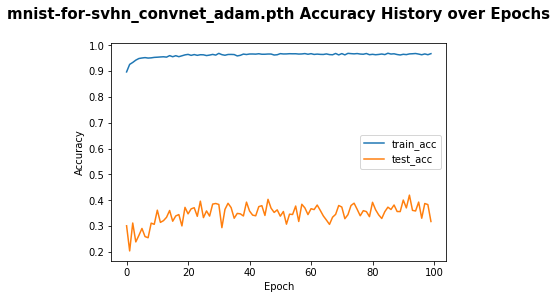

Done!


In [ ]:
model = ConvNetWithDropout(d_out=10, dropout=0.5)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=grayscale_mnist_train_dataloader, 
              validation_dataloader=grayscale_mnist_validation_dataloader, 
              test_dataloader=grayscale_svhn_test_dataloader,
              epochs=100, saved_model_name='mnist-for-svhn_convnet_adam.pth', log_name='mnist-for-svhn_convnet_adam.txt')